C:\Users\judki\anaconda3\Lib\site-packages\missforest\missforest.py:333: UserWarning: Label encoding is no longer performed by default. Users will have to perform categorical features encoding by themselves.
  warnings.warn("Label encoding is no longer performed by default. "
100%|██████████| 5/5 [00:23<00:00,  4.71s/it]
C:\Users\judki\anaconda3\Lib\site-packages\missforest\missforest.py:490: UserWarning: Label encoding is no longer performed by default. Users will have to perform categorical features encoding by themselves.
  warnings.warn("Label encoding is no longer performed by default. "
C:\Users\judki\anaconda3\Lib\site-packages\missforest\missforest.py:494: UserWarning: In version 4.2.3, estimator fitting process is moved to `fit` method. `MissForest` will now imputes unseen missing values with fitted estimators with `transform` method. To retain the old behaviour, use `fit_transform` to fit the whole unseen data instead.
  warnings.warn(f"In version {VERSION}, estimator fitting

=== CATEGORICAL VARIABLES ANALYSIS ===

Frequencies for sex:
Original:
sex
male      676
female    662
Name: count, dtype: int64

After Imputation:
sex
male      729
female    609
Name: count, dtype: int64

Frequencies for smoker:
Original:
smoker
no     1064
yes     274
Name: count, dtype: int64

After Imputation:
smoker
no     1086
yes     252
Name: count, dtype: int64

Frequencies for region:
Original:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

After Imputation:
region
northeast    400
southeast    332
southwest    312
northwest    294
Name: count, dtype: int64

Frequencies for children:
Original:
children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

After Imputation:
children
0.0    634
1.0    296
2.0    223
3.0    143
4.0     25
5.0     17
Name: count, dtype: int64


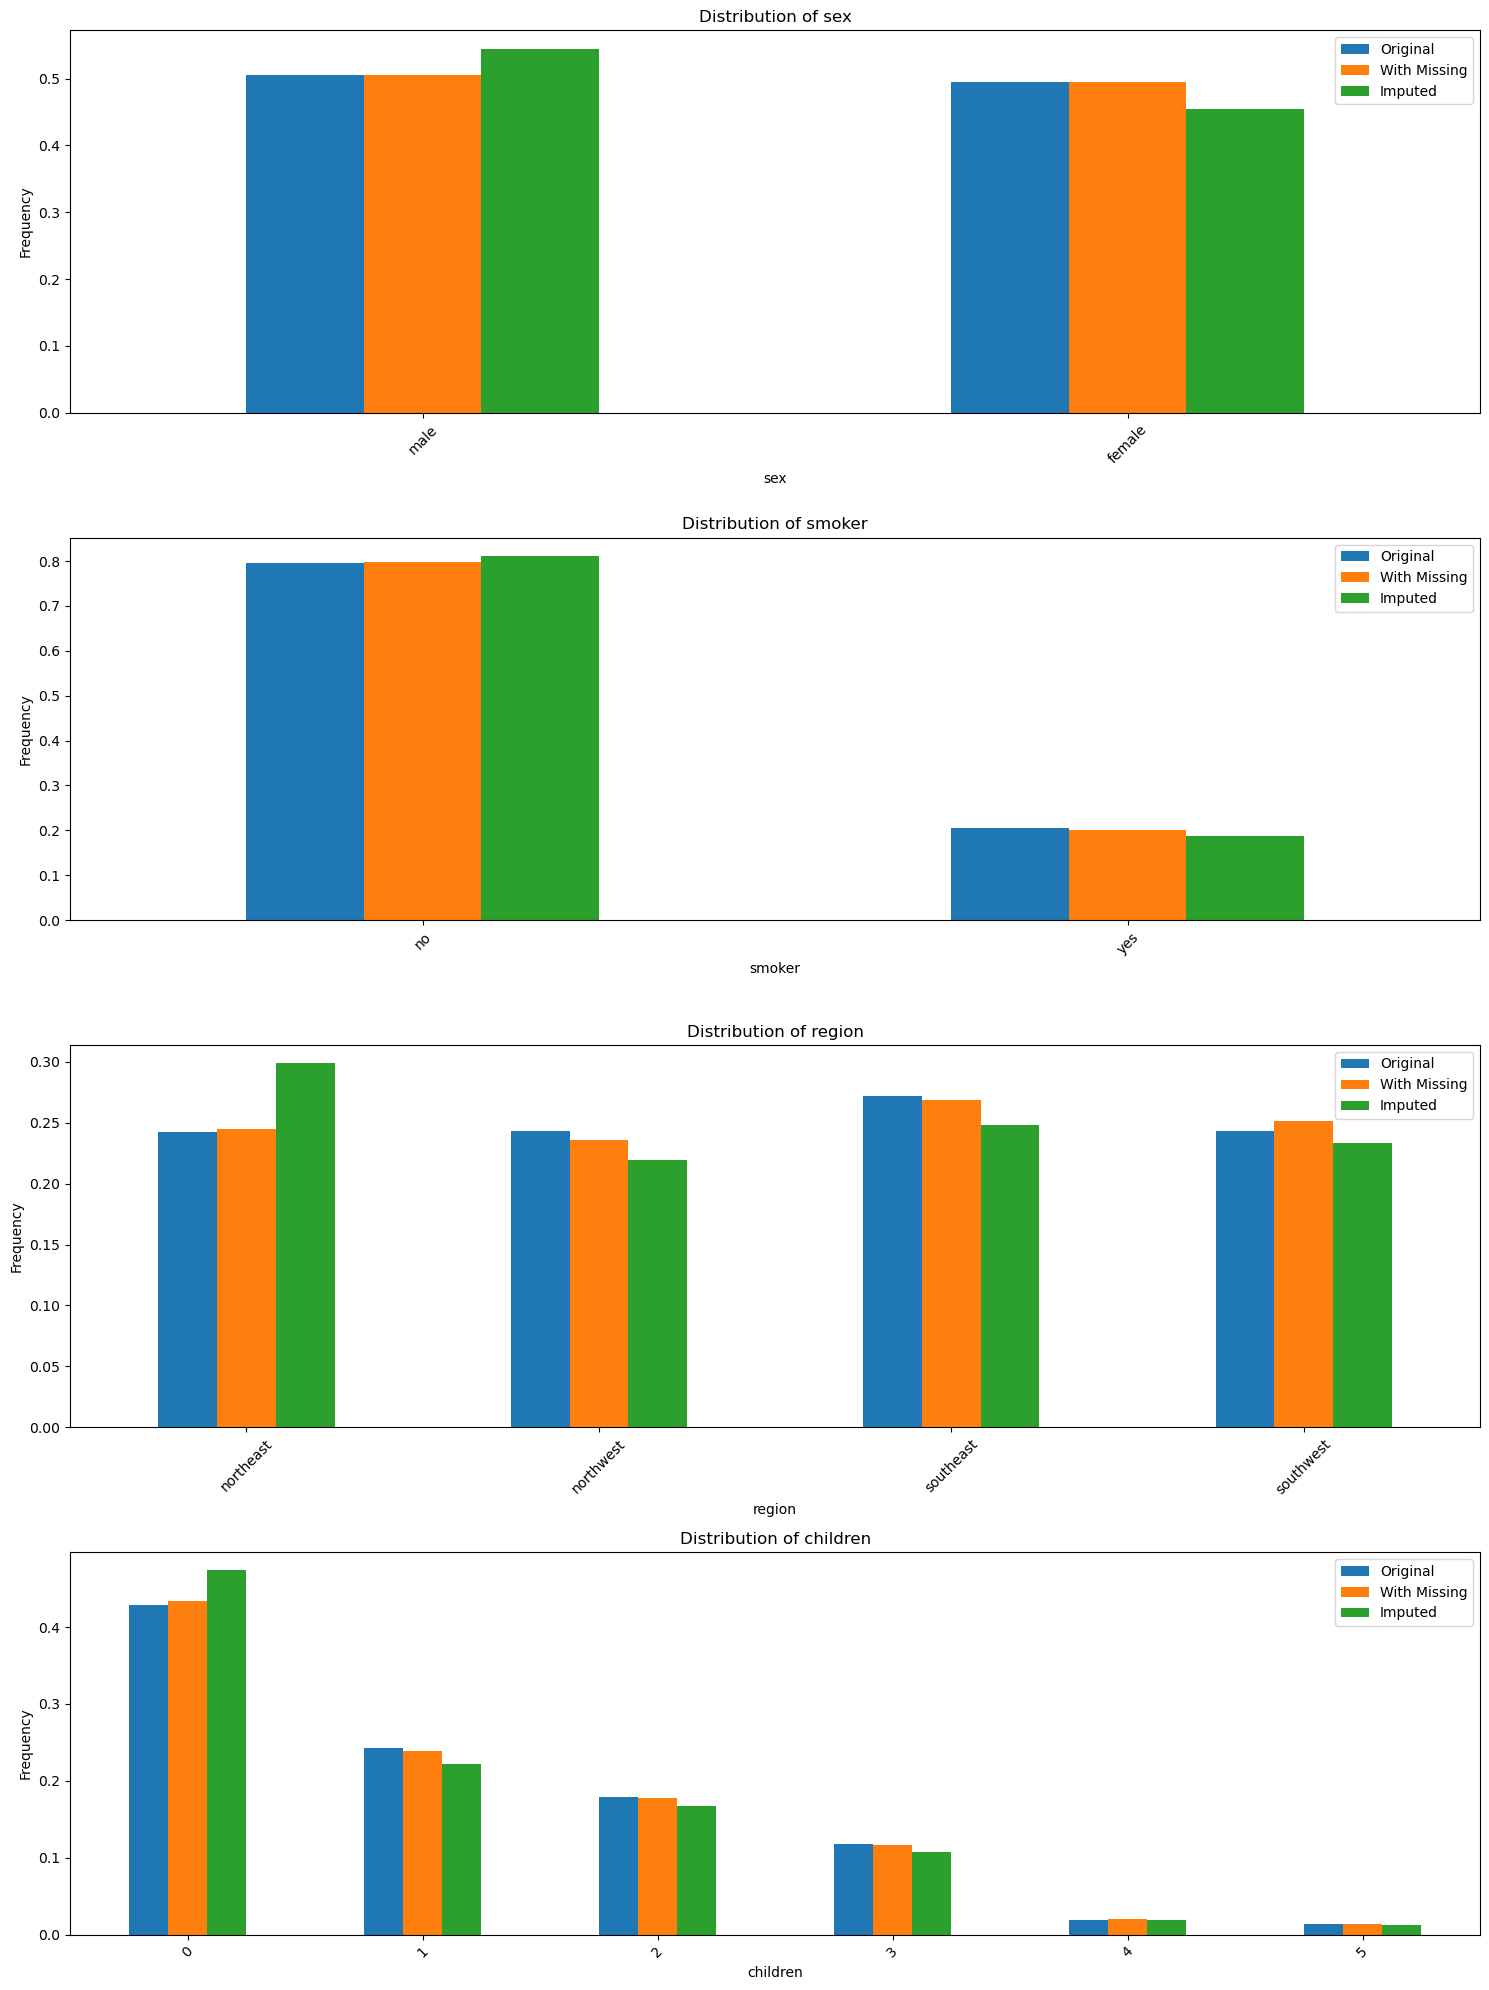


=== NUMERICAL VARIABLES ANALYSIS ===

Statistics for age:
Original:
count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

After Imputation:
count    1338.000000
mean       39.195150
std        13.816407
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

Statistics for bmi:
Original:
count    1338.000000
mean       30.665471
std         6.098382
min        16.000000
25%        26.300000
50%        30.400000
75%        34.700000
max        53.100000
Name: bmi, dtype: float64

After Imputation:
count    1338.000000
mean       30.631580
std         5.889179
min        16.000000
25%        26.400000
50%        30.500000
75%        34.400000
max        52.600000
Name: bmi, dtype: float64

Statistics for expenses:
Original:
count     1338.000000
mean     13270.422414
std   

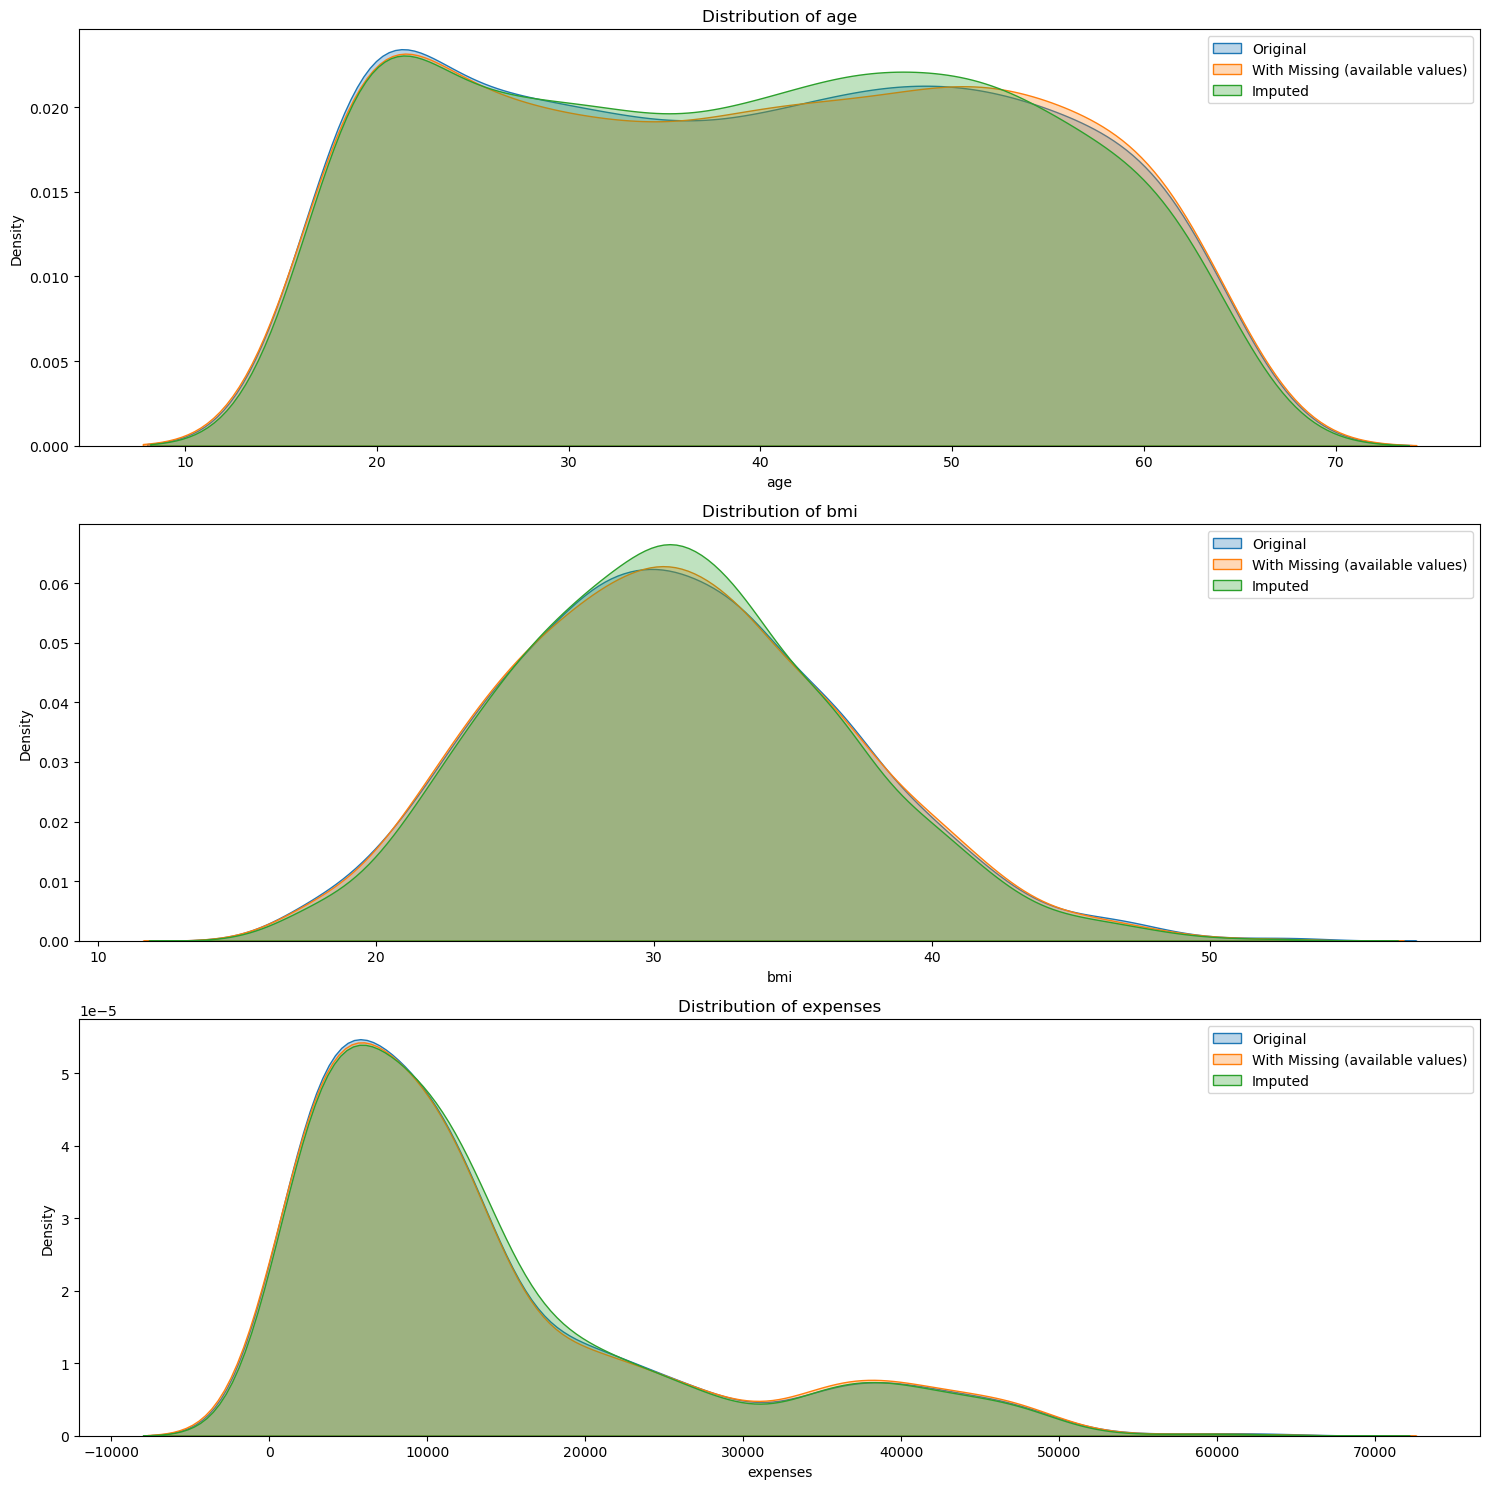

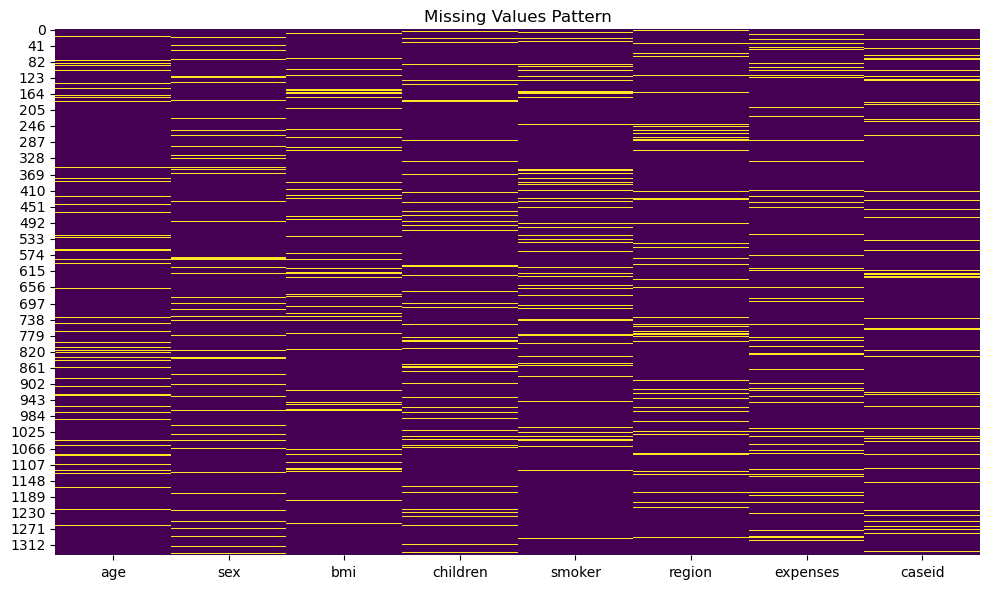

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
expenses    float64
caseid        int64
dtype: object

=== IMPUTATION QUALITY METRICS ===
sex: 55.47% correctly imputed
smoker: 67.97% correctly imputed
region: 25.81% correctly imputed
children: 33.86% correctly imputed
age: RMSE = 18.6789
bmi: RMSE = 8.2602
expenses: RMSE = 18481.0139
ANCOVA Results for Original Data:
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept              -1.194e+04    987.811    -12.089      0.000   -1.39e+04      -1e+04
C(region)[T.northwest]  -352.7901    476.261     -0.741      0.459   -1287.095     581.515
C(region)[T.southeast] -1035.5957    478.681     -2.163      0.031   -1974.648     -96.544
C(region)[T.southwest]  -959.3058    477.912     -2.007      0.045   -1896.850     -21.762
age         

In [1]:
# -*- coding: utf-8 -*-
"""
Created on Sat Mar 21 14:53:11 2026

@author: judki
"""

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from missforest import MissForest
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset with corrected path
df = pd.read_csv("C:\\Users\\judki\\OneDrive\\Documents\\GreatFallsStatistics\\Python training\\insurance.csv")

# Save original data before introducing missing values
df_original = df.copy()

# Label encoding
df["sex"] = df["sex"].map({"male": 0, "female": 1})
df["region"] = df["region"].map({
    "southwest": 0, "southeast": 1, "northwest": 2, "northeast": 3})
df["smoker"] = df["smoker"].map({"yes": 0, "no": 1})

# Create missing values
for c in df.columns:
    n = int(len(df) * 0.1)
    rand_idx = np.random.choice(df.index, n)
    df.loc[rand_idx, c] = np.nan

# Split dataset into train and test sets
train, test = train_test_split(df, test_size=.3, shuffle=True, random_state=42)

categorical = ["sex", "smoker", "region", "children"]
numerical = ["age", "bmi", "expenses"]

# Imputation
mf = MissForest(categorical=categorical)
mf.fit(x=train)
train_imputed = mf.transform(x=train)
test_imputed = mf.transform(x=test)

# Apply the same label encoding to both imputed data and data_with_missing
train_imputed_df = pd.DataFrame(train_imputed, columns=df.columns)
test_imputed_df = pd.DataFrame(test_imputed, columns=df.columns)

# Combine for overall comparison
original_data = df_original.copy()
data_with_missing = df.copy()
imputed_data = pd.concat([train_imputed_df, test_imputed_df])

# Apply reverse mapping to convert numeric codes back to original labels
# First, create reverse mappings based on the original encoding
sex_mapping_reverse = {0: "male", 1: "female"}
region_mapping_reverse = {0: "southwest", 1: "southeast", 2: "northwest", 3: "northeast"}
smoker_mapping_reverse = {0: "yes", 1: "no"}

# Apply reverse mappings to both imputed data and data_with_missing
if "sex" in categorical:
    imputed_data["sex"] = imputed_data["sex"].map(sex_mapping_reverse)
    data_with_missing["sex"] = data_with_missing["sex"].map(sex_mapping_reverse)
    # Ensure original data has the same format for fair comparison
    original_data["sex"] = original_data["sex"].astype(str)

if "region" in categorical:
    imputed_data["region"] = imputed_data["region"].map(region_mapping_reverse)
    data_with_missing["region"] = data_with_missing["region"].map(region_mapping_reverse)
    original_data["region"] = original_data["region"].astype(str)

if "smoker" in categorical:
    imputed_data["smoker"] = imputed_data["smoker"].map(smoker_mapping_reverse)
    data_with_missing["smoker"] = data_with_missing["smoker"].map(smoker_mapping_reverse)
    original_data["smoker"] = original_data["smoker"].astype(str)

def analyze_categorical(original, missing, imputed, cat_vars):
    plt.figure(figsize=(15, len(cat_vars)*5))
    
    for i, var in enumerate(cat_vars):
        plt.subplot(len(cat_vars), 1, i+1)
        
        # Get value counts (frequencies)
        orig_counts = original[var].value_counts(normalize=True)
        miss_counts = missing[var].value_counts(normalize=True)
        imp_counts = imputed[var].value_counts(normalize=True)
        
        # Create a DataFrame for plotting
        counts_df = pd.DataFrame({
            'Original': orig_counts,
            'With Missing': miss_counts,
            'Imputed': imp_counts
        }).fillna(0)
        
        # Plot
        counts_df.plot(kind='bar', ax=plt.gca())
        plt.title(f'Distribution of {var}')
        plt.ylabel('Frequency')
        plt.xticks(rotation=45)
        
        # Print frequencies
        print(f"\nFrequencies for {var}:")
        print("Original:")
        print(original[var].value_counts())
        print("\nAfter Imputation:")
        print(imputed[var].value_counts())
    
    plt.tight_layout()
    plt.show()

# Analyze categorical variables
print("=== CATEGORICAL VARIABLES ANALYSIS ===")
analyze_categorical(original_data, data_with_missing, imputed_data, categorical)

# Function to analyze numerical variables
def analyze_numerical(original, missing, imputed, num_vars):
    plt.figure(figsize=(15, len(num_vars)*5))
    
    for i, var in enumerate(num_vars):
        plt.subplot(len(num_vars), 1, i+1)
        
        # Plot distributions
        sns.kdeplot(original[var], label='Original', fill=True, alpha=0.3)
        sns.kdeplot(missing[var].dropna(), label='With Missing (available values)', fill=True, alpha=0.3)
        sns.kdeplot(imputed[var], label='Imputed', fill=True, alpha=0.3)
        
        plt.title(f'Distribution of {var}')
        plt.legend()
        
        # Print statistics
        print(f"\nStatistics for {var}:")
        print("Original:")
        print(original[var].describe())
        print("\nAfter Imputation:")
        print(imputed[var].describe())
    
    plt.tight_layout()
    plt.show()
    
# First, ensure numerical columns are actually numeric
# Convert numerical columns to appropriate types before analysis
original_data[numerical] = original_data[numerical].apply(pd.to_numeric, errors='coerce')
data_with_missing[numerical] = data_with_missing[numerical].apply(pd.to_numeric, errors='coerce')
imputed_data[numerical] = imputed_data[numerical].apply(pd.to_numeric, errors='coerce')

# Analyze numerical variables
print("\n=== NUMERICAL VARIABLES ANALYSIS ===")
analyze_numerical(original_data, data_with_missing, imputed_data, numerical)

# Create a missing values heatmap to visualize the pattern of missingness
plt.figure(figsize=(10, 6))
sns.heatmap(data_with_missing.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Pattern')
plt.tight_layout()
plt.show()


print (original_data.dtypes)

# restore orinial order
original_data = original_data.sort_values(by="caseid")
data_with_missing = data_with_missing.sort_values(by="caseid")
imputed_data = imputed_data.sort_values(by="caseid")

# Reset indices after sorting 
original_data = original_data.reset_index()
data_with_missing = data_with_missing.reset_index()
imputed_data = imputed_data.reset_index()

# Calculate imputation accuracy metrics
print("\n=== IMPUTATION QUALITY METRICS ===")
# For categorical variables, calculate match percentage with original values
for cat in categorical:
    # Get indices where values were missing
    missing_idx = data_with_missing[cat].isna()
    if missing_idx.sum() > 0:
        # Calculate percentage of correct imputations
        matches = (imputed_data.loc[missing_idx, cat] == original_data.loc[missing_idx, cat]).mean() * 100
        print(f"{cat}: {matches:.2f}% correctly imputed")

# For numerical variables, calculate RMSE between original and imputed values
for num in numerical:
    missing_idx = data_with_missing[num].isna()
    if missing_idx.sum() > 0:
        rmse = np.sqrt(((imputed_data.loc[missing_idx, num] - original_data.loc[missing_idx, num]) ** 2).mean())
        print(f"{num}: RMSE = {rmse:.4f}")
  
# Compare multivariate models of expenses in terms of covariates across original and imputed data.        
  
# Import necessary libraries
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
import numpy as np

# Assuming original_data and imputed_data are already defined
# Convert region to categorical in all three datasets
original_data['region'] = pd.Categorical(original_data['region'])
imputed_data['region'] = pd.Categorical(imputed_data['region'])
data_with_missing['region'] = pd.Categorical(data_with_missing['region'])

# Convert smoker and sex to binary numeric variables if they aren't already
for df in [original_data, imputed_data, data_with_missing]:
    if df['smoker'].dtype == 'object':
        df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})
    if df['sex'].dtype == 'object':
        df['sex'] = df['sex'].map({'male': 1, 'female': 0})

# Define the formula for ANCOVA
# Using C() to specify region as categorical
formula = 'expenses ~ age + sex + bmi + children + smoker + C(region)'

# Run ANCOVA on original data
model_original = smf.ols(formula, data=original_data).fit()

# Run ANCOVA on imputed data
model_imputed = smf.ols(formula, data=imputed_data).fit()

# Run ANCOVA on censored data
model_censored = smf.ols(formula, data=data_with_missing).fit()

# Create a DataFrame to compare coefficients
coef_comparison = pd.DataFrame({
    'Original Data': model_original.params,
    'Imputed Data': model_imputed.params,
    'Censored Data':model_censored.params,
    'Difference wimp': model_imputed.params - model_original.params,
    'Difference woimp': model_censored.params - model_original.params})

# Add p-values
coef_comparison['Original p-value'] = model_original.pvalues
coef_comparison['Imputed p-value'] = model_imputed.pvalues
coef_comparison['Censored p-value'] = model_censored.pvalues

# Print the summary of all three models
print("ANCOVA Results for Original Data:")
print(model_original.summary().tables[1])
print("\nANCOVA Results for Imputed Data:")
print(model_imputed.summary().tables[1])
print("\nANCOVA Results for Censored Data:")
print(model_censored.summary().tables[1])

# Print the coefficient comparison
print("\nCoefficient Comparison:")
with pd.option_context('display.float_format', '{:.0f}'.format):
    print(coef_comparison[['Difference wimp', 'Difference woimp']])
    
# Print the pavalues side-by-side
print("\np-value Comparison:")
with pd.option_context('display.float_format', '{:.3f}'.format):
    print(coef_comparison[['Original p-value', 'Imputed p-value', 'Censored p-value']])

# Optional: Calculate and print the R-squared comparison
print("\nR-squared Comparison:")
print(f"Original Data R-squared: {model_original.rsquared:.4f}")
print(f"Imputed Data R-squared: {model_imputed.rsquared:.4f}")
print(f"Censored Data R-squared: {model_censored.rsquared:.4f}")

#Missforest is distoring the relationship between children and expenses